Paquetes necesarios

Hacemos uso del mismo *environment* de la primera práctica

In [45]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt
import pygame
from PIL import Image, ImageDraw, ImageFont

img = cv2.imread('mandril.jpg')

if img is None:
    print("Error: No se ha encontrado la imagen 'mandril.jpg'.")
    exit()

gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

TAREA 1: Realiza la cuenta de píxeles blancos por filas (en lugar de por columnas). Determina el valor máximo de píxeles blancos para filas, maxfil, mostrando el número de filas y sus respectivas posiciones, con un número de píxeles blancos mayor o igual que 0.90*maxfil. Resalta con alguna primitiva gráfica en la imagen de Canny las filas que cumplen dicha condición.

Valor máximo de píxeles blancos en una fila: 220.0
Número de filas que superan el 90% del máximo: 7
Posiciones de las filas: [  6  12  15  20  21  88 100]


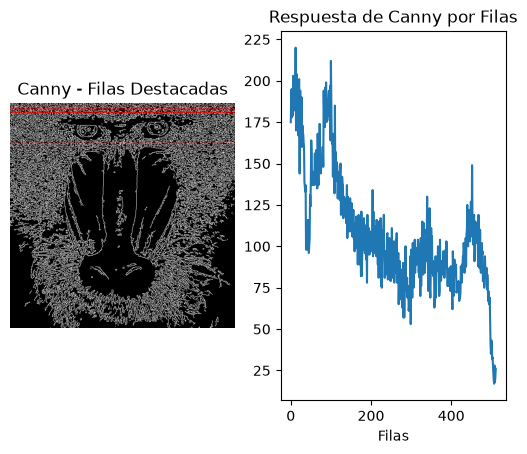

In [46]:
canny = cv2.Canny(gris, 100, 200)

# Cuenta el número de píxeles blancos por fila
row_counts = cv2.reduce(canny, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

rows = row_counts[:, 0] / 255

# Valor máximo de píxeles blancos por filas
maxfil = np.max(rows)

# Filas que cumplen la condición >= 0.90 * maxfil
condicion = 0.90 * maxfil
filas_destacadas = np.where(rows >= condicion)[0]

print(f"Valor máximo de píxeles blancos en una fila: {maxfil}")
print(f"Número de filas que superan el 90% del máximo: {len(filas_destacadas)}")
print(f"Posiciones de las filas: {filas_destacadas}")

# Marcamos con líneas rojas en la imagen de Canny
# Convertimos Canny a BGR para dibujar en color
canny_resaltado = cv2.cvtColor(canny, cv2.COLOR_GRAY2BGR)
for f in filas_destacadas:
    cv2.line(canny_resaltado, (0, f), (canny.shape[1], f), (255, 0, 0), 1)

plt.subplot(1, 2, 1)
plt.title("Canny - Filas Destacadas")
plt.axis("off")
plt.imshow(canny_resaltado)

plt.subplot(1, 2, 2)
plt.title("Respuesta de Canny por Filas")
plt.xlabel("Filas")
plt.ylabel("% Píxeles")
plt.plot(range(len(rows)), rows)
plt.show()

TAREA 2: Aplica umbralizado a la imagen resultante de Sobel (convertida a 8 bits), y posteriormente realiza el conteo por filas y columnas similar al realizado en el ejemplo con la salida de Canny de píxeles no nulos. Calcula el valor máximo de la cuenta por filas y columnas, y determina las filas y columnas por encima del 0.90*máximo. Remarca con alguna primitiva gráfica dichas filas y columnas sobre la imagen del mandril. Visualiza los resultados obtenidos para la imagen (o una de tu elección) con Canny y Sobe tras umbralizar ¿Cómo se comparan los resultados obtenidos a partir de Sobel y Canny?

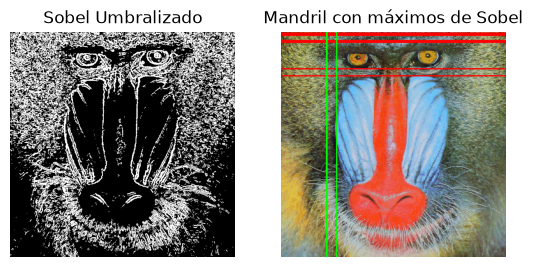

In [47]:
ggris = cv2.GaussianBlur(gris, (3, 3), 0)
sobelx = cv2.Sobel(ggris, cv2.CV_64F, 1, 0)
sobely = cv2.Sobel(ggris, cv2.CV_64F, 0, 1)
# Combinar con valor absoluto para evitar pérdida de bordes negativos
sobel = cv2.add(np.abs(sobelx), np.abs(sobely))
sobel8 = cv2.convertScaleAbs(sobel)

# Aplicar umbralizado a la imagen Sobel
valor_umbral = 100
_, sobel_umbralizada = cv2.threshold(sobel8, valor_umbral, 255, cv2.THRESH_BINARY)

# Conteo por filas y columnas
row_counts_sobel = cv2.reduce(sobel_umbralizada, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)[:, 0] / 255
col_counts_sobel = cv2.reduce(sobel_umbralizada, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)[0] / 255

maxfil_sobel = np.max(row_counts_sobel)
maxcol_sobel = np.max(col_counts_sobel)

filas_destacadas_sobel = np.where(row_counts_sobel >= 0.90 * maxfil_sobel)[0]
cols_destacadas_sobel = np.where(col_counts_sobel >= 0.90 * maxcol_sobel)[0]

# Marcar sobre la imagen original
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
for f in filas_destacadas_sobel:
    cv2.line(img_rgb, (0, f), (img.shape[1], f), (255, 0, 0), 2) # Líneas rojas horizontales
for c in cols_destacadas_sobel:
    cv2.line(img_rgb, (c, 0), (c, img.shape[0]), (0, 255, 0), 2) # Líneas verdes verticales

plt.subplot(1, 2, 1)
plt.title("Sobel Umbralizado")
plt.axis("off")
plt.imshow(sobel_umbralizada, cmap='gray')

plt.subplot(1, 2, 2)
plt.title("Mandril con máximos de Sobel")
plt.axis("off")
plt.imshow(img_rgb)
plt.show()

Comparativa Canny vs Sobel:
En la práctica, Sobel resulta un poco menos preciso, nos da bordes bastante gruesos y algo borrosos porque depende totalmente del umbral que le pongamos. Además, si la imagen tiene mucha textura, Sobel se confunde y detecta demasiados píxeles.

Canny, en cambio, hace un trabajo mucho más limpio. Como aplica pasos extra para limpiar la imagen (como la supresión de no-máximos y la histéresis), logra dibujar líneas nítidas de un solo píxel de grosor. Básicamente, Canny consigue capturar el contorno real y la estructura de la imagen de forma mucho más precisa que Sobel.

TAREA 3: Tras ver los vídeos [My little piece of privacy](https://www.niklasroy.com/project/88/my-little-piece-of-privacy), [Messa di voce](https://youtu.be/GfoqiyB1ndE?feature=shared) y [Virtual air guitar](https://youtu.be/FIAmyoEpV5c?feature=shared) proponer un demostrador reinterpretando la parte de procesamiento de la imagen, tomando como punto de partida alguna de dichas instalaciones.

In [48]:
# Inicializar el sistema de audio
pygame.mixer.init()

# Cargar el audio
try:
    sonido_amarillo = pygame.mixer.Sound("amarillo.mp3") 
except:
    sonido_amarillo = None

vid = cv2.VideoCapture(0)

amarillo_bajo = np.array([20, 100, 100])
amarillo_alto = np.array([35, 255, 255])

while True:
    ret, frame = vid.read()
    if not ret:
        break

    # Efecto espejo
    framem = cv2.flip(frame, 1)
    
    # BGR a HSV
    hsv = cv2.cvtColor(framem, cv2.COLOR_BGR2HSV)
    
    # Máscara para detectar el amarillo
    mask = cv2.inRange(hsv, amarillo_bajo, amarillo_alto)
    
    # Limpiar el ruido
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_DILATE, kernel, iterations=2)
    
    # Buscar contornos
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    objeto_amarillo_en_pantalla = False

    if contours:
        # Coger el contorno amarillo más grande
        c = max(contours, key=cv2.contourArea)
        
        if cv2.contourArea(c) > 500:
            objeto_amarillo_en_pantalla = True
            x, y, w, h = cv2.boundingRect(c)
            
            # Dibujar la cortina de censura
            cv2.rectangle(framem, (x - 20, 0), (x + w + 20, framem.shape[0]), (0, 0, 0), -1)
            cv2.putText(framem, "AMARILLO CENSURADO", (x, 50), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
            
            # get_busy() para que no empiece a sonar encima de sí mismo
            if sonido_amarillo and not pygame.mixer.get_busy():
                sonido_amarillo.play()

    # La música se corta de golpe en cuanto se quita el objeto amarillo de la cámara
    if not objeto_amarillo_en_pantalla and sonido_amarillo:
        pygame.mixer.stop()

    cv2.imshow('Cortina Anti-Amarillo', framem)
    
    if cv2.waitKey(20) == 27:
        break

vid.release()
pygame.quit() # Cerrar pygame al salir
cv2.destroyAllWindows()